In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("dirty_cafe_sales.csv")

print(df.head())

  Transaction ID    Item Quantity Price Per Unit Total Spent  Payment Method  \
0    TXN_1961373  Coffee        2            2.0         4.0     Credit Card   
1    TXN_4977031    Cake        4            3.0        12.0            Cash   
2    TXN_4271903  Cookie        4            1.0       ERROR     Credit Card   
3    TXN_7034554   Salad        2            5.0        10.0         UNKNOWN   
4    TXN_3160411  Coffee        2            2.0         4.0  Digital Wallet   

   Location Transaction Date  
0  Takeaway       2023-09-08  
1  In-store       2023-05-16  
2  In-store       2023-07-19  
3   UNKNOWN       2023-04-27  
4  In-store       2023-06-11  


In [3]:
print(df.shape)

(10000, 8)


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB
None


In [5]:
print(df.describe())

       Transaction ID   Item Quantity Price Per Unit Total Spent  \
count           10000   9667     9862           9821        9827   
unique          10000     10        7              8          19   
top       TXN_9226047  Juice        5            3.0         6.0   
freq                1   1171     2013           2429         979   

        Payment Method  Location Transaction Date  
count             7421      6735             9841  
unique               5         4              367  
top     Digital Wallet  Takeaway          UNKNOWN  
freq              2291      3022              159  


In [6]:
print(df.isnull().sum())

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64


In [7]:
df.replace(["ERROR", "UNKNOWN"], np.nan, inplace=True)

In [8]:
numeric_cols = ["Quantity", "Price Per Unit", "Total Spent"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [9]:
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_1391/3154000584.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [10]:
df["Item"].fillna(df["Item"].mode()[0], inplace=True)

df["Payment Method"].fillna(
    df["Payment Method"].mode()[0],
    inplace=True
)

df["Location"].fillna(
    df["Location"].mode()[0],
    inplace=True
)

/tmp/ipykernel_1391/4172850927.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Item"].fillna(df["Item"].mode()[0], inplace=True)
/tmp/ipykernel_1391/4172850927.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df["Transaction Date"] = pd.to_datetime(
    df["Transaction Date"]
)

In [13]:
df["Month"] = df["Transaction Date"].dt.month

df["Day"] = df["Transaction Date"].dt.day_name()

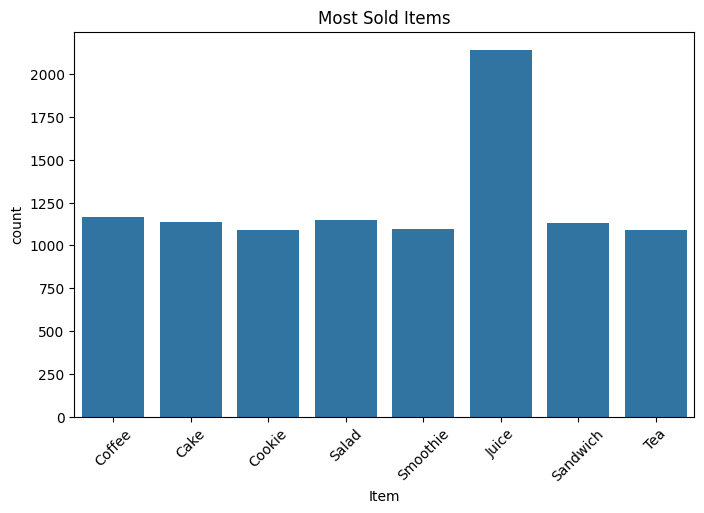

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(x="Item", data=df)

plt.title("Most Sold Items")

plt.xticks(rotation=45)

plt.show()

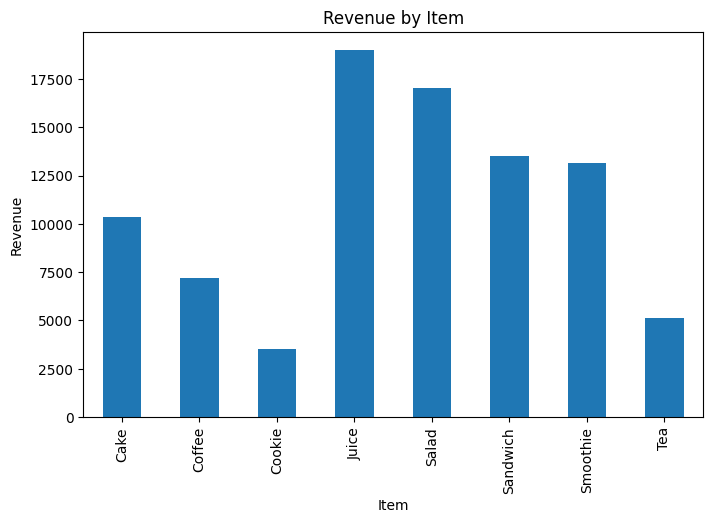

In [15]:
sales = df.groupby("Item")["Total Spent"].sum()

sales.plot(kind='bar', figsize=(8,5))

plt.title("Revenue by Item")

plt.ylabel("Revenue")

plt.show()

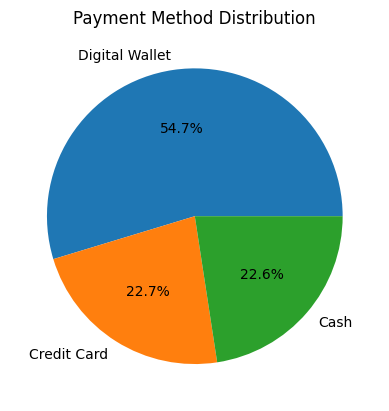

In [16]:
df["Payment Method"].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Payment Method Distribution")

plt.ylabel("")

plt.show()

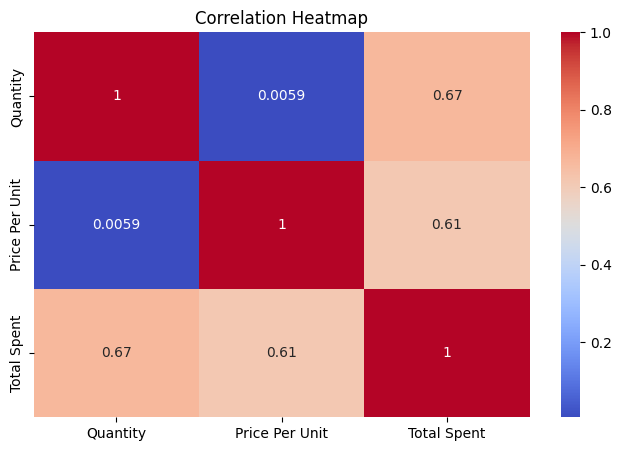

In [17]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[["Quantity",
        "Price Per Unit",
        "Total Spent"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

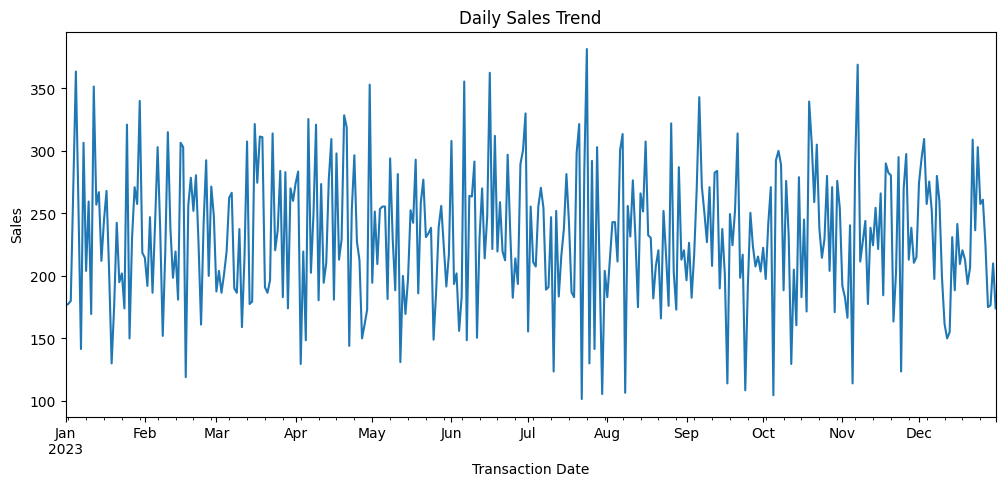

In [18]:
daily_sales = df.groupby(
    "Transaction Date"
)["Total Spent"].sum()

daily_sales.plot(figsize=(12,5))

plt.title("Daily Sales Trend")

plt.ylabel("Sales")

plt.show()

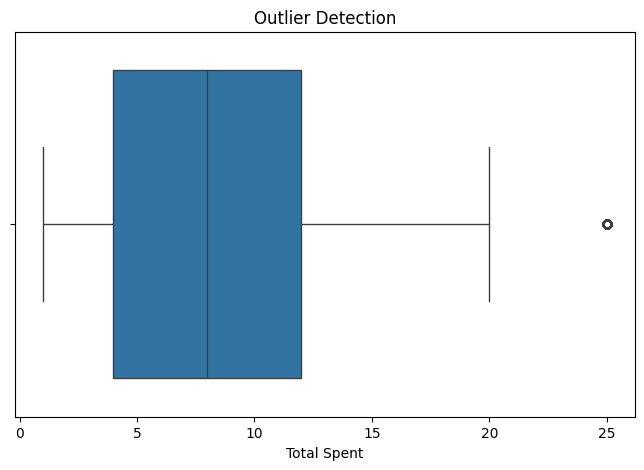

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Total Spent"])

plt.title("Outlier Detection")

plt.show()

In [21]:
df.to_csv(
    "cleaned_cafe_sales.csv",
    index=False
)